# Test `cscas_grouping` on AIT-ADS

Quick sandbox to try the new `group_alerts_cscas` method (signature + host session grouping, bounded by `session_length`/`session_timeout`) on a raw AIT-ADS scenario, and compare it against `fixed_window` (2s).

In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from thesis.paths import ROOT
from thesis.schemas.preprocessing import IncomingAlert
from thesis.preprocessing.parsing import parse_incoming_alert
from thesis.preprocessing.tokenization import tokenize_alert
from thesis.grouping.group_alerts import (
    group_alerts_cscas,
    group_alerts_fixed_window,
    FIXED_WINDOW_SECONDS,
    CSCAS_METHOD,
)

# chart chrome (dataviz skill reference palette)
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
COLOR_CSCAS = "#2a78d6"  # categorical slot 1 (blue)
COLOR_FIXED_WINDOW = "#1baf7a"  # categorical slot 2 (aqua)
COLOR_SESSION_LENGTH = ["#2a78d6", "#1baf7a", "#eda100"]  # slots 1-3, fixed order


def style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color(INK_MUTED)
    ax.tick_params(colors=INK_SECONDARY, length=0)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1)
    ax.set_axisbelow(True)
    ax.title.set_color(INK_PRIMARY)
    ax.xaxis.label.set_color(INK_SECONDARY)
    ax.yaxis.label.set_color(INK_SECONDARY)

### Load a scenario's raw alerts into `TokenizedAlert`s

Mirrors `pipeline.convert_ait_alerts_to_json` + `process_alert_batch`, without touching the on-disk cache.

In [2]:
scenario = "wheeler"  # fox | harrison | russellmitchell | santos | shaw | wardbeck | wheeler | wilson
alerts_path = ROOT / "data" / "alerts_csv" / f"{scenario}_alerts.txt"

tokenized_alerts = []
with alerts_path.open("r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        incoming = IncomingAlert.from_row(
            {
                "time": int(row["time"]),
                "signature": row["name"],
                "ip": row["ip"],
                "host": row["host"],
                "short": row["short"],
                "label": row["time_label"],
                "event_label": row["event_label"],
            }
        )
        parsed = parse_incoming_alert(alert=incoming, scenario=scenario)
        tokenized_alerts.append(tokenize_alert(parsed))

print(f"Loaded {len(tokenized_alerts)} alerts for scenario '{scenario}'")

Loaded 616161 alerts for scenario 'wheeler'


### Run `cscas_grouping`

In [3]:
session_length = 300.0  # max total span of a session, seconds
session_timeout = 2.0  # max gap between consecutive alerts, seconds

cscas_records = group_alerts_cscas(
    tokenized_alerts,
    session_length=session_length,
    session_timeout=session_timeout,
)

cscas_df = pd.DataFrame(
    [{"alert_id": r.alert_id, "group_id": r.group_id, "method": r.method} for r in cscas_records]
)
print(f"{len(cscas_records)} alerts -> {cscas_df['group_id'].nunique()} groups")
cscas_df["group_id"].value_counts().describe()

616161 alerts -> 45306 groups


count     45306.000000
mean         13.599987
std         965.570576
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max      121924.000000
Name: count, dtype: float64

### Compare against `fixed_window` (2s, no host/signature split)

In [4]:
fw_records = group_alerts_fixed_window(tokenized_alerts, window_size=FIXED_WINDOW_SECONDS)
fw_df = pd.DataFrame(
    [{"alert_id": r.alert_id, "group_id": r.group_id, "method": r.method} for r in fw_records]
)
print(f"{len(fw_records)} alerts -> {fw_df['group_id'].nunique()} groups")

print("\ngroup-size distributions:")
print("cscas_grouping:\n", cscas_df["group_id"].value_counts().describe())
print("\nfixed_window (2s):\n", fw_df["group_id"].value_counts().describe())

616161 alerts -> 20981 groups

group-size distributions:
cscas_grouping:
 count     45306.000000
mean         13.599987
std         965.570576
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max      121924.000000
Name: count, dtype: float64

fixed_window (2s):
 count    20981.000000
mean        29.367571
std        132.312304
min          1.000000
25%          3.000000
50%          6.000000
75%         10.000000
max       1480.000000
Name: count, dtype: float64


#### Plot: group-size distribution

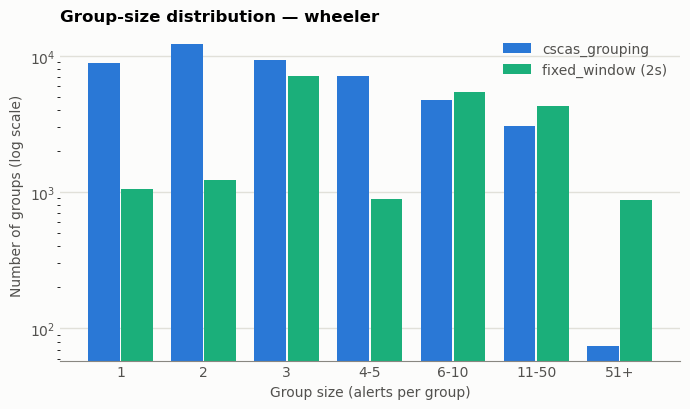

In [5]:
bucket_edges = [0, 1, 2, 3, 5, 10, 50, np.inf]
bucket_labels = ["1", "2", "3", "4-5", "6-10", "11-50", "51+"]

cscas_sizes = cscas_df["group_id"].value_counts()
fw_sizes = fw_df["group_id"].value_counts()

cscas_buckets = pd.cut(cscas_sizes, bins=bucket_edges, labels=bucket_labels).value_counts().reindex(bucket_labels)
fw_buckets = pd.cut(fw_sizes, bins=bucket_edges, labels=bucket_labels).value_counts().reindex(bucket_labels)

x = np.arange(len(bucket_labels))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(7, 4.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.bar(x - bar_width / 2 - 0.01, cscas_buckets.values, bar_width, color=COLOR_CSCAS, label="cscas_grouping")
ax.bar(x + bar_width / 2 + 0.01, fw_buckets.values, bar_width, color=COLOR_FIXED_WINDOW, label="fixed_window (2s)")

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(bucket_labels)
ax.set_xlabel("Group size (alerts per group)")
ax.set_ylabel("Number of groups (log scale)")
ax.set_title(f"Group-size distribution — {scenario}", loc="left", fontsize=12, fontweight="bold")
style_axes(ax)
ax.legend(frameon=False, labelcolor=INK_SECONDARY)

fig.tight_layout()
plt.show()

### Sweep `session_timeout` / `session_length`

In [6]:
rows = []
for timeout in (1.0, 2.0, 5.0, 30.0, 60.0):
    for length in (60.0, 300.0, 900.0):
        recs = group_alerts_cscas(tokenized_alerts, session_length=length, session_timeout=timeout)
        n_groups = len({r.group_id for r in recs})
        rows.append(
            {
                "session_timeout": timeout,
                "session_length": length,
                "n_alerts": len(recs),
                "n_groups": n_groups,
                "avg_group_size": len(recs) / n_groups if n_groups else 0,
            }
        )

sweep_df = pd.DataFrame(rows)
sweep_df

,session_timeout,session_length,n_alerts,n_groups,avg_group_size
0,1.0,60.0,616161,47391,13.001646
1,1.0,300.0,616161,47365,13.008783
2,1.0,900.0,616161,47361,13.009882
3,2.0,60.0,616161,45332,13.592187
4,2.0,300.0,616161,45306,13.599987
5,2.0,900.0,616161,45302,13.601188
6,5.0,60.0,616161,40495,15.215730
7,5.0,300.0,616161,40458,15.229646
8,5.0,900.0,616161,40452,15.231904
9,30.0,60.0,616161,25902,23.788163


#### Plot: number of groups vs. `session_timeout`, by `session_length`

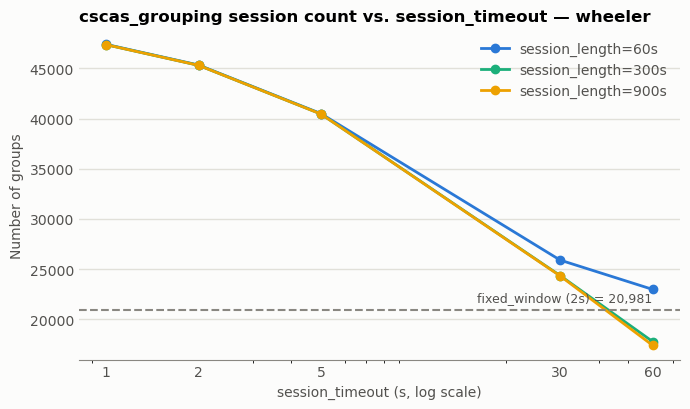

In [7]:
fw_n_groups = fw_df["group_id"].nunique()

fig, ax = plt.subplots(figsize=(7, 4.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for color, length in zip(COLOR_SESSION_LENGTH, sorted(sweep_df["session_length"].unique())):
    line = sweep_df[sweep_df["session_length"] == length].sort_values("session_timeout")
    ax.plot(
        line["session_timeout"],
        line["n_groups"],
        color=color,
        linewidth=2,
        marker="o",
        markersize=6,
        label=f"session_length={int(length)}s",
    )

ax.axhline(fw_n_groups, color=INK_MUTED, linewidth=1.5, linestyle="--")
ax.annotate(
    f"fixed_window (2s) = {fw_n_groups:,}",
    xy=(sweep_df["session_timeout"].max(), fw_n_groups),
    xytext=(0, 6),
    textcoords="offset points",
    ha="right",
    color=INK_SECONDARY,
    fontsize=9,
)

ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(sorted(sweep_df["session_timeout"].unique()))
ax.set_xlabel("session_timeout (s, log scale)")
ax.set_ylabel("Number of groups")
ax.set_title(f"cscas_grouping session count vs. session_timeout — {scenario}", loc="left", fontsize=12, fontweight="bold")
style_axes(ax)
ax.legend(frameon=False, labelcolor=INK_SECONDARY)

fig.tight_layout()
plt.show()